In [40]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('../Data/healthcare_data_cleaned.csv')

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   has_hypertension   5110 non-null   int64  
 4   has_heart_disease  5110 non-null   int64  
 5   marital_status     5110 non-null   int64  
 6   employment_type    5110 non-null   str    
 7   residence          5110 non-null   str    
 8   glucose_level      5110 non-null   float64
 9   bmi_value          5110 non-null   float64
 10  smoking_habit      5110 non-null   str    
 11  stroke_event       5110 non-null   int64  
 12  age_group          5110 non-null   str    
 13  risk_score         5110 non-null   int64  
 14  high_glucose       5110 non-null   int64  
 15  bmi_category       5110 non-null   str    
 16  lifestyle_risk     5110 non-null   

In [41]:
print(df.describe().transpose())

                    count          mean           std    min        25%  \
patient_id         5110.0  36517.829354  21161.721625  67.00  17741.250   
age                5110.0     43.226614     22.612647   0.08     25.000   
has_hypertension   5110.0      0.097456      0.296607   0.00      0.000   
has_heart_disease  5110.0      0.054012      0.226063   0.00      0.000   
marital_status     5110.0      0.656164      0.475034   0.00      0.000   
glucose_level      5110.0    106.147677     45.283560  55.12     77.245   
bmi_value          5110.0     29.116614      7.778400  10.30     23.800   
stroke_event       5110.0      0.048728      0.215320   0.00      0.000   
risk_score         5110.0      0.151468      0.391924   0.00      0.000   
high_glucose       5110.0      0.160665      0.367258   0.00      0.000   
bmi_was_missing    5110.0      0.039335      0.194409   0.00      0.000   

                         50%       75%       max  
patient_id         36932.000  54682.00  72940.00

In [42]:
#df = df.drop(columns=['bmi_missing'])
df = df.set_index('patient_id')

# 3. Convert string columns to categorical data types
string_columns = [
    'gender', 'employment_type', 'residence', 'smoking_habit', 
    'age_group', 'bmi_category', 'lifestyle_risk'
]

#Apply the conversion
for col in string_columns:
    df[col] = df[col].astype('category')


print(df.info())

<class 'pandas.DataFrame'>
Index: 5110 entries, 30669 to 43424
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5110 non-null   category
 1   age                5110 non-null   float64 
 2   has_hypertension   5110 non-null   int64   
 3   has_heart_disease  5110 non-null   int64   
 4   marital_status     5110 non-null   int64   
 5   employment_type    5110 non-null   category
 6   residence          5110 non-null   category
 7   glucose_level      5110 non-null   float64 
 8   bmi_value          5110 non-null   float64 
 9   smoking_habit      5110 non-null   category
 10  stroke_event       5110 non-null   int64   
 11  age_group          5110 non-null   category
 12  risk_score         5110 non-null   int64   
 13  high_glucose       5110 non-null   int64   
 14  bmi_category       5110 non-null   category
 15  lifestyle_risk     5110 non-null   category
 16  bmi_was_missing  

In [43]:
bmi_mapping = {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}
age_mapping = {'young': 0, 'middle': 1, 'senior': 2}
risk_mapping = {'low': 0, 'medium': 1, 'high': 2}

df['bmi_category'] = df['bmi_category'].map(bmi_mapping)
df['age_group'] = df['age_group'].map(age_mapping)
df['lifestyle_risk'] = df['lifestyle_risk'].map(risk_mapping)

In [44]:
nominal_columns = ['gender', 'employment_type', 'residence', 'smoking_habit']

df = pd.get_dummies(df, columns=nominal_columns, drop_first=True)
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

In [45]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
Index: 5110 entries, 30669 to 43424
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       5110 non-null   float64 
 1   has_hypertension          5110 non-null   int64   
 2   has_heart_disease         5110 non-null   int64   
 3   marital_status            5110 non-null   int64   
 4   glucose_level             5110 non-null   float64 
 5   bmi_value                 5110 non-null   float64 
 6   stroke_event              5110 non-null   int64   
 7   age_group                 5110 non-null   category
 8   risk_score                5110 non-null   int64   
 9   high_glucose              5110 non-null   int64   
 10  bmi_category              5110 non-null   category
 11  lifestyle_risk            5110 non-null   category
 12  bmi_was_missing           5110 non-null   int64   
 13  gender_M                  5110 non-null   int64   
 14  emp

stroke_event
0    95.127202
1     4.872798
Name: proportion, dtype: float64


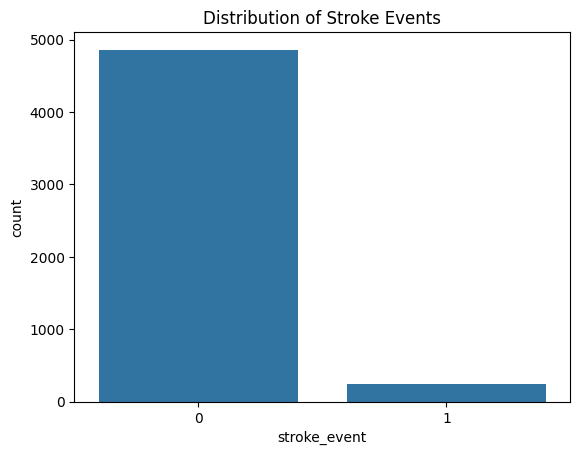

In [46]:
print(df['stroke_event'].value_counts(normalize=True) * 100)

# Visualize it
sns.countplot(x='stroke_event', data=df)
plt.title('Distribution of Stroke Events')
plt.show()

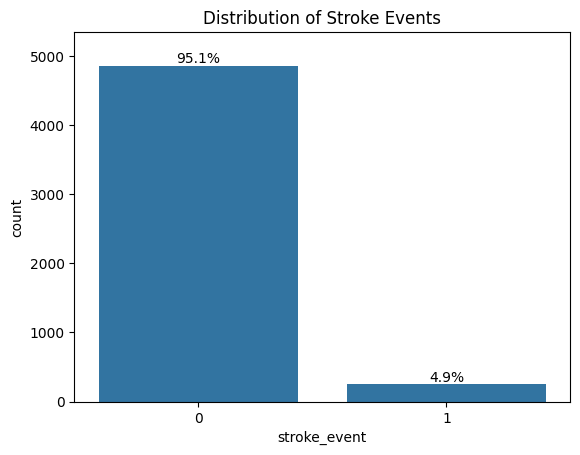

In [50]:
# Create the plot and save it to the variable 'ax'
ax = sns.countplot(x='stroke_event', data=df)
plt.title('Distribution of Stroke Events')

# Calculate the total number of rows to find the percentage
total = len(df)

# Loop through each bar in the graph
for p in ax.patches:
    # Calculate the percentage
    percentage = f'{100 * p.get_height() / total:.1f}%'
    
    # Get the X and Y coordinates for the text
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    
    # Place the text on the graph
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

# Adjust layout so the text doesn't get cut off at the top
plt.ylim(0, df['stroke_event'].value_counts().max() * 1.1)
plt.show()

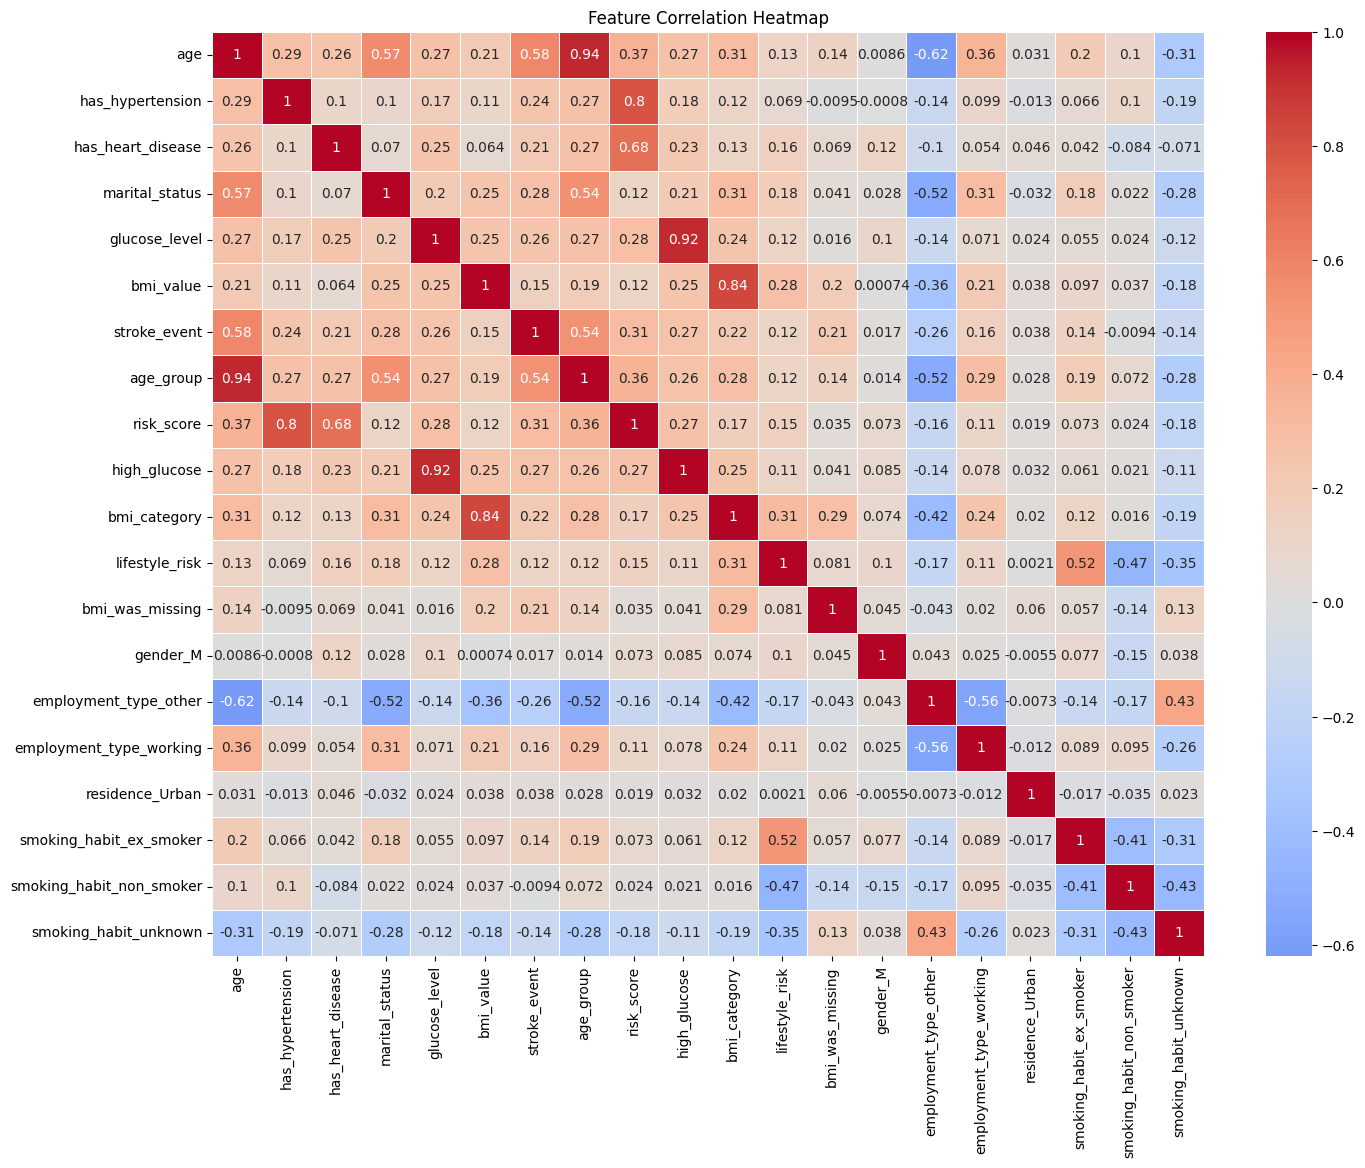

stroke_event      1.000000
age               0.579175
age_group         0.535163
risk_score        0.308860
marital_status    0.277239
high_glucose      0.265051
Name: stroke_event, dtype: float64


In [32]:
plt.figure(figsize=(16, 12))

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap, focusing on how everything correlates to 'stroke_event'
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            annot=True, # Keep False to avoid cluttering a 20x20 grid
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Print the top 5 features most highly correlated with a stroke
print(corr_matrix['stroke_event'].sort_values(ascending=False).head(6))

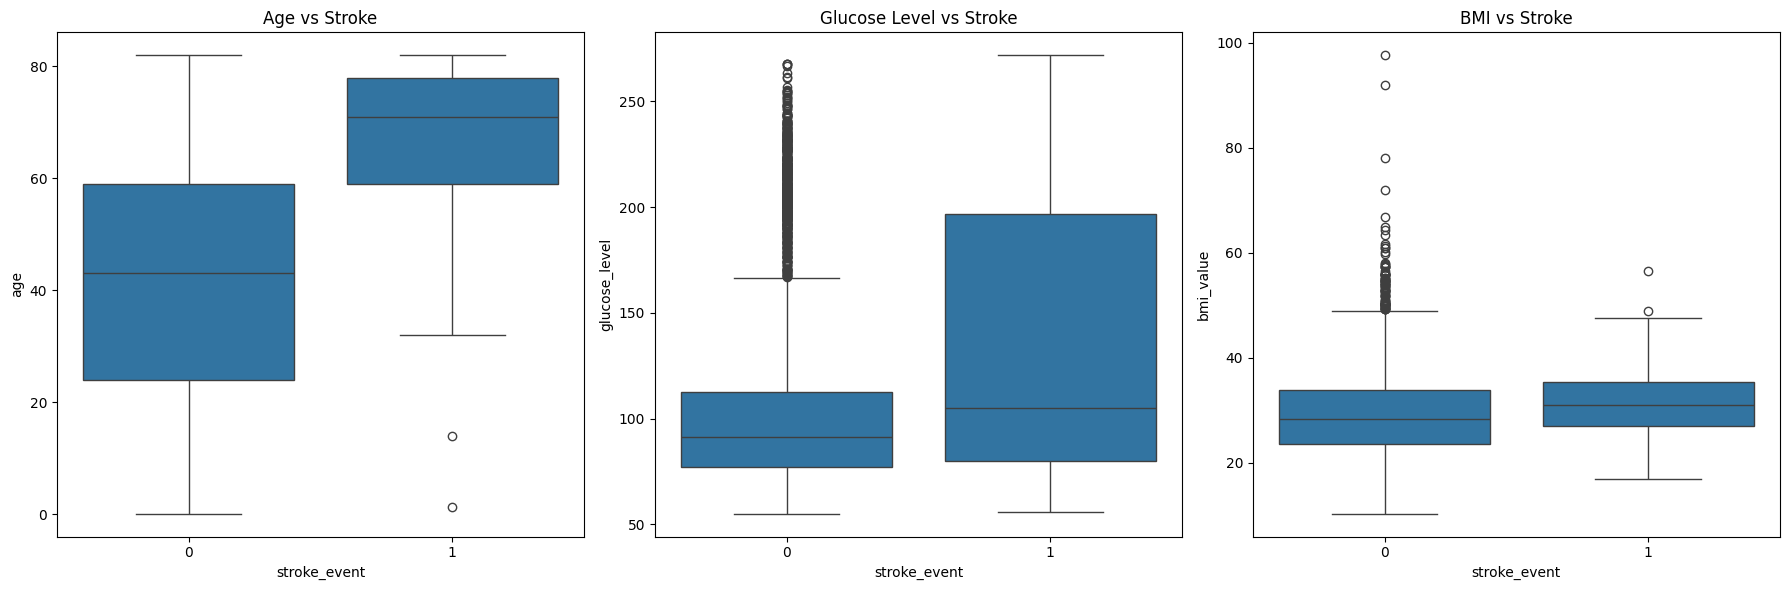

In [51]:
# Create a grid of boxplots for continuous variables
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(ax=axes[0], x='stroke_event', y='age', data=df)
axes[0].set_title('Age vs Stroke')

sns.boxplot(ax=axes[1], x='stroke_event', y='glucose_level', data=df)
axes[1].set_title('Glucose Level vs Stroke')

sns.boxplot(ax=axes[2], x='stroke_event', y='bmi_value', data=df)
axes[2].set_title('BMI vs Stroke')

plt.tight_layout()
plt.show()

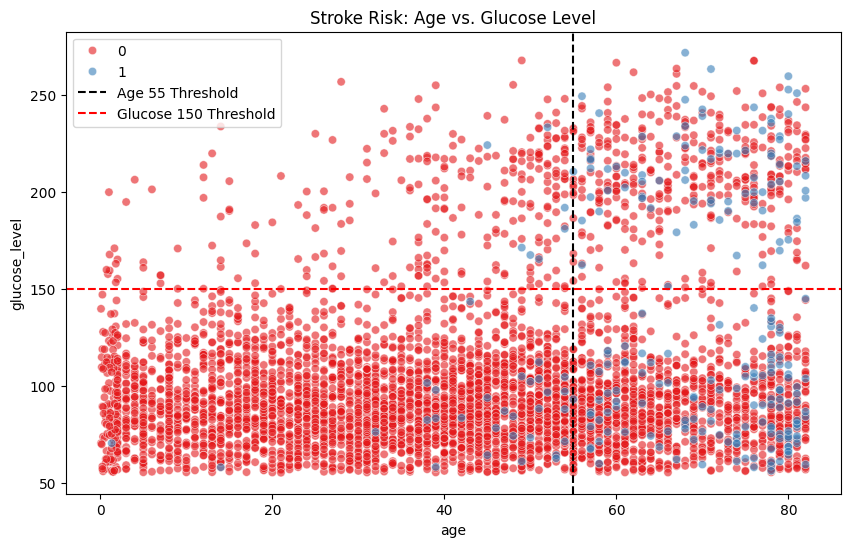

In [52]:
plt.figure(figsize=(10, 6))

# Plot Age vs Glucose, coloring the dots based on whether they had a stroke
sns.scatterplot(
    data=df, 
    x='age', 
    y='glucose_level', 
    hue='stroke_event', 
    alpha=0.6,
    palette='Set1'
)

plt.title('Stroke Risk: Age vs. Glucose Level')
plt.axvline(x=55, color='black', linestyle='--', label='Age 55 Threshold')
plt.axhline(y=150, color='red', linestyle='--', label='Glucose 150 Threshold')
plt.legend()
plt.show()

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

stroke_patients = df[df['stroke_event'] == 1].copy()
X_stroke = stroke_patients.drop(columns=['stroke_event', 'bmi_was_missing'])

scaler_kmeans = StandardScaler()
X_stroke_scaled = scaler_kmeans.fit_transform(X_stroke)

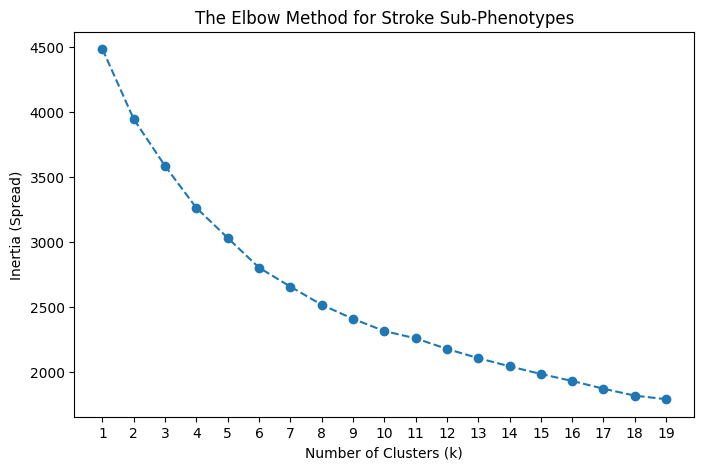

In [55]:
inertia = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_stroke_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('The Elbow Method for Stroke Sub-Phenotypes')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Spread)')
plt.xticks(K_range)
plt.show()

Stroke Sub-Phenotype Profiles (Averages per Cluster):
------------------------------------------------------------
                   age  glucose_level  bmi_value  has_hypertension  \
Cluster_Profile                                                      
0                67.93          88.91      29.44              0.23   
1                68.65         201.43      33.72              0.33   
2                 7.66          64.15      33.15              0.00   

                 has_heart_disease  
Cluster_Profile                     
0                             0.10  
1                             0.33  
2                             0.00  


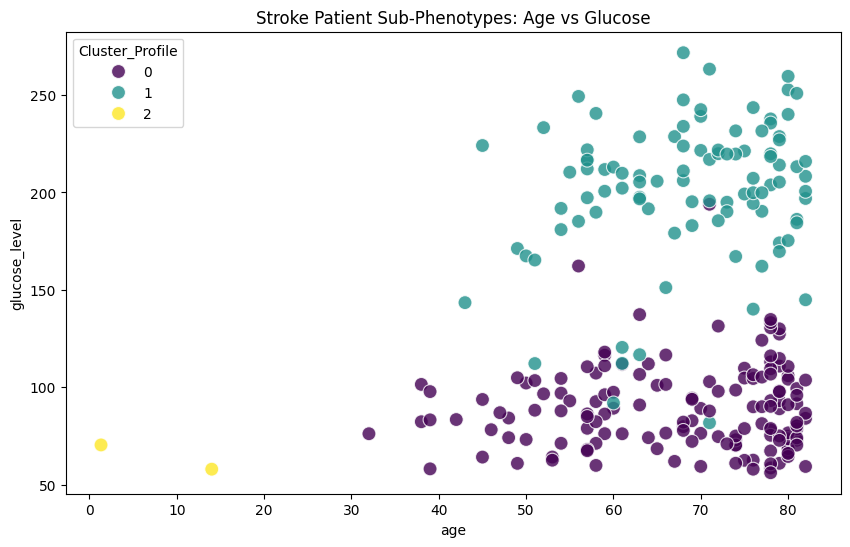

In [57]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Assign the cluster labels (0, 1, 2, or 3) back to our original dataframe
stroke_patients['Cluster_Profile'] = kmeans.fit_predict(X_stroke_scaled)

# Calculate the mean for the most critical features in each cluster
profile_summary = stroke_patients.groupby('Cluster_Profile')[['age', 'glucose_level', 'bmi_value', 'has_hypertension', 'has_heart_disease']].mean()

print("Stroke Sub-Phenotype Profiles (Averages per Cluster):")
print("-" * 60)
print(profile_summary.round(2))


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=stroke_patients, 
    x='age', 
    y='glucose_level', 
    hue='Cluster_Profile', 
    palette='viridis', 
    s=100, 
    alpha=0.8
)
plt.title('Stroke Patient Sub-Phenotypes: Age vs Glucose')
plt.show()